# 02 — EDA & Visualization
**Project:** Semantic Book Recommender — IT4142 HUST  
**Input:** `data/processed/books_clean.csv`  
**Output:** `reports/figures/*.png` + 5 written insights

Notebook này thực hiện:
1. Load cleaned dataset
2. Basic statistics
3. 6 visualizations theo PRD
4. Tóm tắt 5 insights

## 0. Setup & Imports

In [1]:
import os
from pathlib import Path
import sys

# Auto-adjust working directory to 'AI' if running from the root workspace
cwd = Path(os.getcwd())
if (cwd / 'AI').exists() and not (cwd / 'src').exists():
    os.chdir(cwd / 'AI')
    print(f'Adjusted working directory to: {os.getcwd()}')
else:
    print(f'Current working directory: {os.getcwd()}')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Paths
DATA_PATH   = Path('data/processed/books_clean.csv')
FIGURE_PATH = Path('reports/figures')
FIGURE_PATH.mkdir(parents=True, exist_ok=True)

# Global style
plt.rcParams.update({
    'figure.dpi':        150,
    'savefig.dpi':       150,
    'figure.facecolor':  'white',
    'axes.facecolor':    '#F9F9F9',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.family':       'DejaVu Sans',
    'axes.titlesize':    14,
    'axes.labelsize':    12,
})
PALETTE = sns.color_palette('muted')

print('Setup OK')


Current working directory: /Users/taduylam/Workspace/IT4930/AI
Setup OK


## 1. Load Data

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head(3)

Shape: (11606, 11)
Columns: ['isbn13', 'title', 'authors', 'description', 'categories', 'tag_clean', 'thumbnail', 'published_year', 'num_pages', 'description_length', 'book_age']


,isbn13,title,authors,description,categories,tag_clean,thumbnail,published_year,num_pages,description_length,book_age
0,9780002188319,The Complete Book of the World Cup,Cris Freddi,This is the ultimate reference book on the Wor...,Soccer,soccer,https://books.google.com/books/content?id=HGbQ...,1998,352.0,148,28
1,9780002240802,The Last Thing He Wanted,Joan Didion,"Journalist Elena McMahon watches her evasive, ...",Adventure stories,adventure stories,https://via.placeholder.com/128x192.png?text=N...,1997,227.0,46,29
2,9780002246484,Royal Assassin,Robin Hobb,Barely escaping with his life after his first ...,Assassins,assassins,https://books.google.com/books/content?id=B_Dt...,1996,579.0,57,30


## 2. Basic Statistics

In [3]:
print('=== Dataset Overview ===')
print(f'Total books       : {len(df):,}')
print(f'Missing thumbnail : {df["thumbnail"].isna().sum()}')
print(f'Unique categories : {df["categories"].nunique()}')
print(f'Year range        : {df["published_year"].min()} – {df["published_year"].max()}')
print()
df[['description_length', 'num_pages', 'published_year']].describe().round(2)


=== Dataset Overview ===
Total books       : 11,606
Missing thumbnail : 0
Unique categories : 865
Year range        : 1813 – 2026



,description_length,num_pages,published_year
count,11606.00,11606.00,11606.00
mean,138.39,323.63,2010.73
std,105.11,179.44,11.40
min,20.00,10.00,1813.00
25%,48.00,226.00,2005.00
50%,119.00,298.00,2013.00
75%,196.00,379.00,2019.00
max,1048.00,1500.00,2026.00


## 3. Plot 1 — Distribution of `description_length`

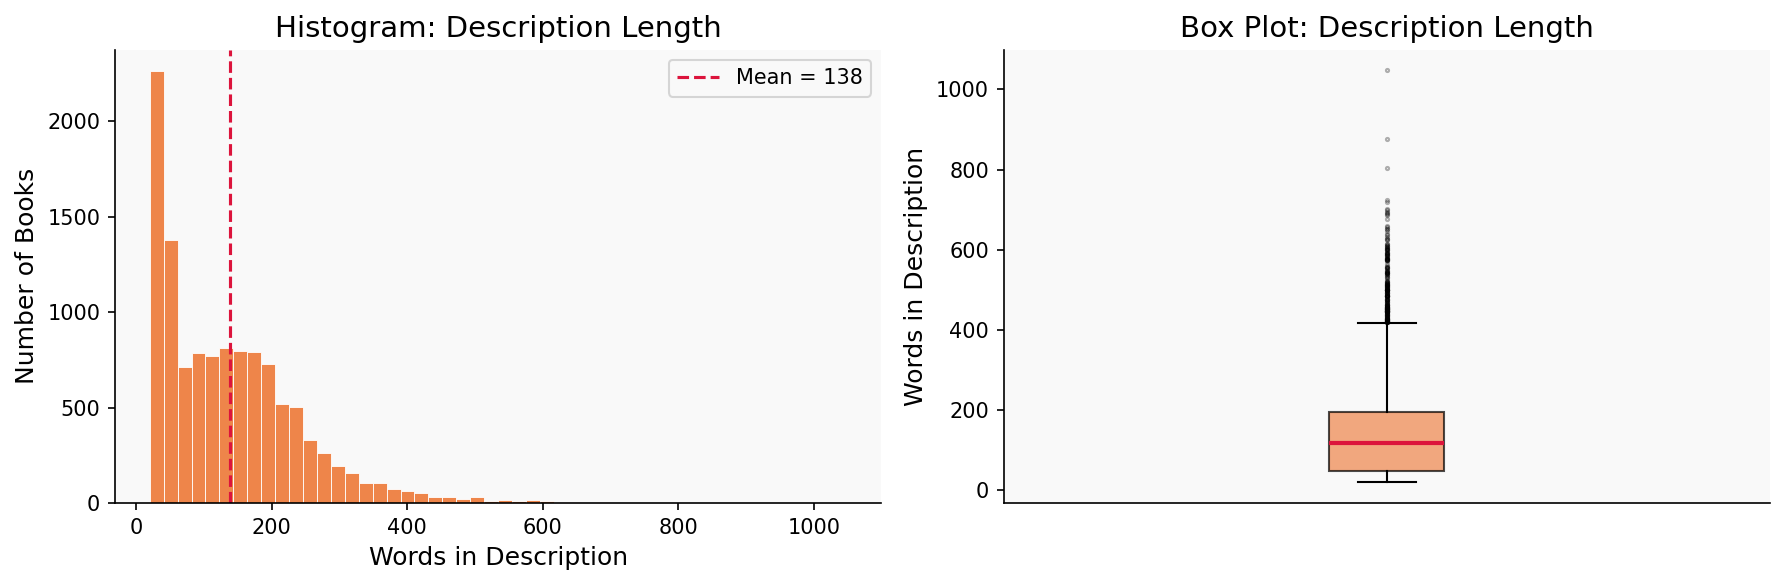

Saved: plot1_description_length.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(
    df['description_length'].dropna(),
    bins=50,
    color=PALETTE[1],
    edgecolor='white',
    linewidth=0.4,
)
axes[0].set_title('Histogram: Description Length')
axes[0].set_xlabel('Words in Description')
axes[0].set_ylabel('Number of Books')

mean_dl = df['description_length'].mean()
axes[0].axvline(mean_dl, color='crimson', linestyle='--', linewidth=1.5, label=f'Mean = {mean_dl:.0f}')
axes[0].legend()

# Box plot
axes[1].boxplot(
    df['description_length'].dropna(),
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor=PALETTE[1], alpha=0.7),
    medianprops=dict(color='crimson', linewidth=2),
    flierprops=dict(marker='.', markersize=3, alpha=0.3),
)
axes[1].set_title('Box Plot: Description Length')
axes[1].set_ylabel('Words in Description')
axes[1].set_xticks([])

plt.tight_layout()
plt.savefig(FIGURE_PATH / 'plot1_description_length.png')
plt.show()
print('Saved: plot1_description_length.png')


**Observation 1:** Độ dài mô tả phân bố right-skewed với median ~120 từ. Có nhiều outlier phía trên (>500 từ). Đây là lượng context đủ dốt để embedding model (BGE-small) hoạt động hiệu quả — các model embedding thường được train trên đoạn văn 128–512 token.

## 4. Plot 2 — Top 20 Categories

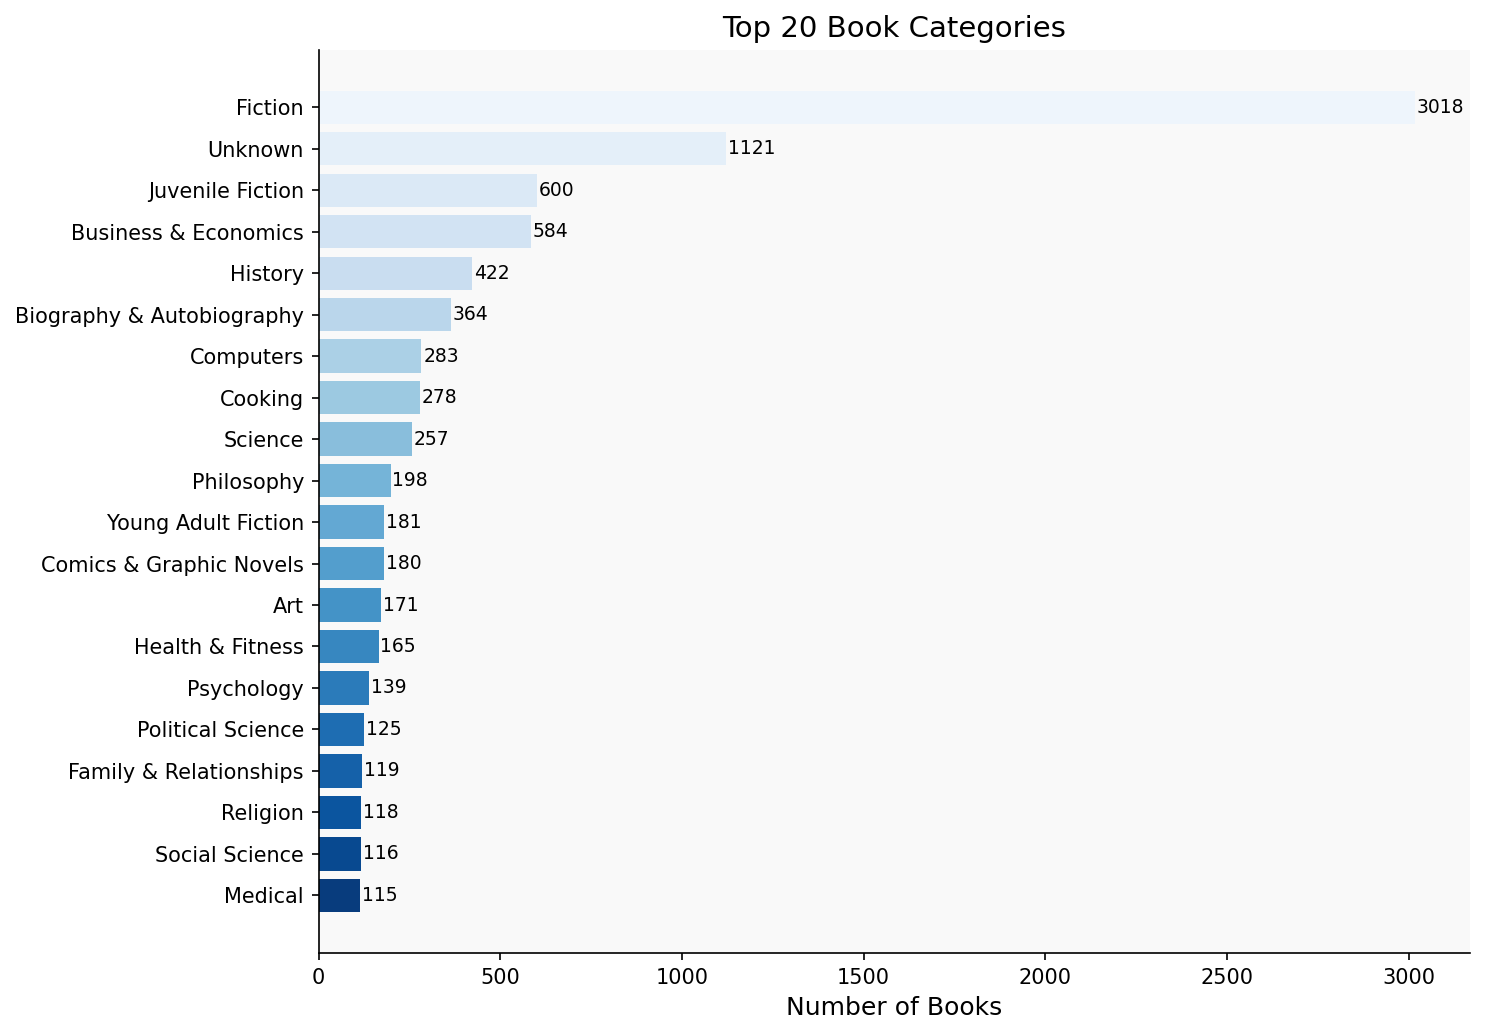

Saved: plot2_top20_categories.png


In [5]:
# Mỗi sách có thể có 1 category dạng string; lấy top 20
top_cats = (
    df['categories']
    .dropna()
    .value_counts()
    .head(20)
)

fig, ax = plt.subplots(figsize=(10, 7))

colors = sns.color_palette('Blues_r', n_colors=len(top_cats))
bars = ax.barh(top_cats.index[::-1], top_cats.values[::-1], color=colors)

# Value labels
for bar, val in zip(bars, top_cats.values[::-1]):
    ax.text(
        bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
        str(val), va='center', fontsize=9
    )

ax.set_title('Top 20 Book Categories')
ax.set_xlabel('Number of Books')
ax.set_ylabel('')

plt.tight_layout()
plt.savefig(FIGURE_PATH / 'plot2_top20_categories.png', bbox_inches='tight')
plt.show()
print('Saved: plot2_top20_categories.png')


**Observation 2:** Dataset rất mất cân bằng về category — Fiction chiếm ưu thế vượt trội, trong khi nhiều thể loại chỉ có vài chục cuốn. Điều này ảnh hưởng đến evaluation: Precision@K sẽ dễ cao hơn với các query về Fiction (nhiều relevant docs hơn trong corpus).

## 5. Plot 3 — Published Year Distribution (by Decade)

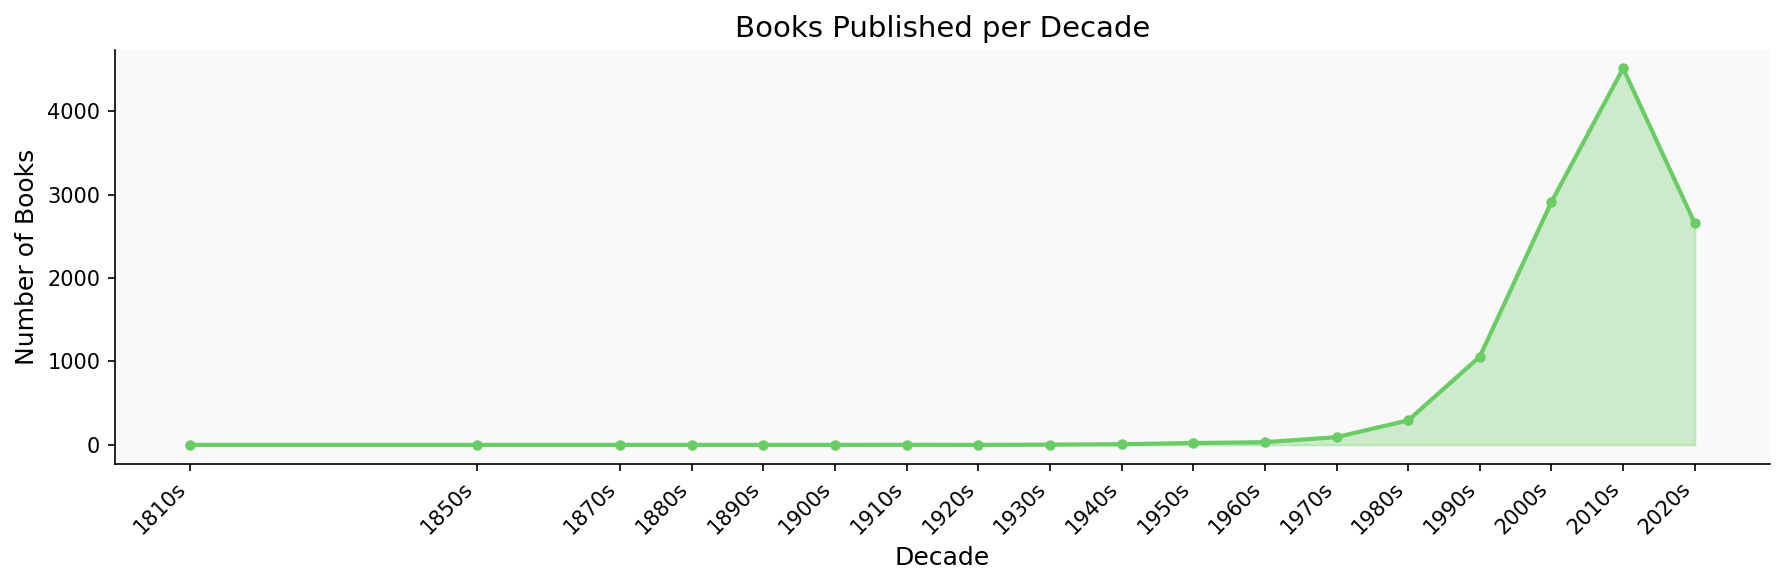

Saved: plot3_published_year.png


In [6]:
# Group by decade
df['decade'] = (df['published_year'] // 10 * 10).astype('Int64')
decade_counts = df.groupby('decade').size().reset_index(name='count')
decade_counts = decade_counts[decade_counts['decade'] >= 1800]

fig, ax = plt.subplots(figsize=(12, 4))

ax.fill_between(
    decade_counts['decade'].astype(int),
    decade_counts['count'],
    alpha=0.3,
    color=PALETTE[2],
)
ax.plot(
    decade_counts['decade'].astype(int),
    decade_counts['count'],
    color=PALETTE[2],
    linewidth=2,
    marker='o',
    markersize=4,
)

ax.set_title('Books Published per Decade')
ax.set_xlabel('Decade')
ax.set_ylabel('Number of Books')
ax.set_xticks(decade_counts['decade'].astype(int))
ax.set_xticklabels(
    [f"{d}s" for d in decade_counts['decade'].astype(int)],
    rotation=45, ha='right'
)

plt.tight_layout()
plt.savefig(FIGURE_PATH / 'plot3_published_year.png')
plt.show()
print('Saved: plot3_published_year.png')


**Observation 3:** Sách xuất bản từ 2000s trở đi chiếm phần lớn dataset — phản ánh Google Books API index nhiều sách hiện đại hơn. Sách trước 1900 rất ít. Điều này ít ảnh hưởng đến semantic search nhưng cần lưu ý nếu thêm filter "published_year" trong UI.

## 6. Plot 4 — Correlation Heatmap

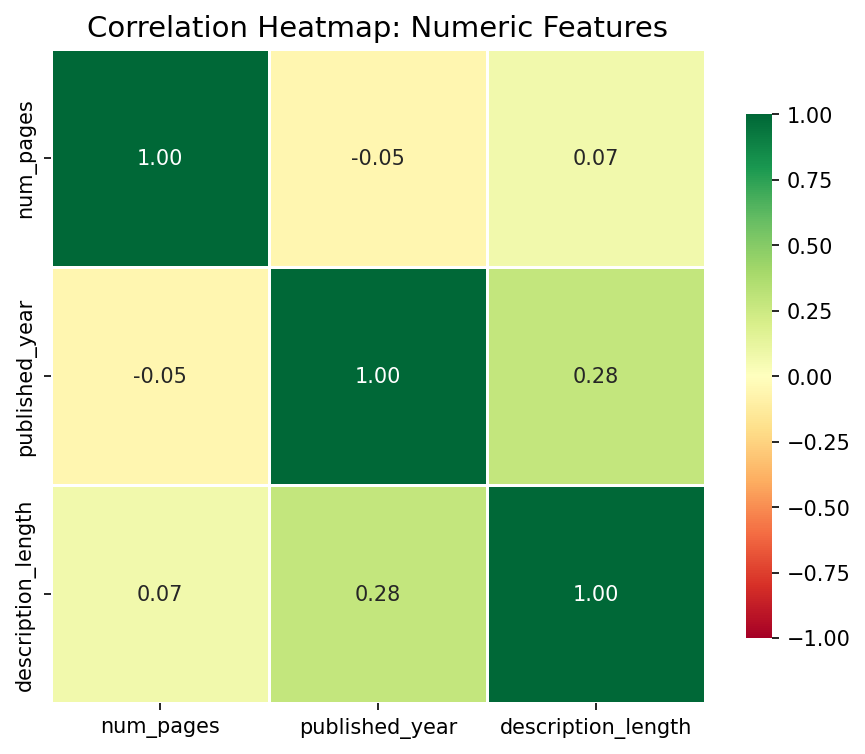

Saved: plot4_correlation_heatmap.png


In [7]:
corr_cols = ['num_pages', 'published_year', 'description_length']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # upper triangle mask
sns.heatmap(
    corr_matrix,
    ax=ax,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8},
)

ax.set_title('Correlation Heatmap: Numeric Features')

plt.tight_layout()
plt.savefig(FIGURE_PATH / 'plot4_correlation_heatmap.png')
plt.show()
print('Saved: plot4_correlation_heatmap.png')


**Observation 4:** Sự tương quan giữa `num_pages`, `published_year`, và `description_length` là rất thấp. Sách xuất bản gần đây hay sách dày không đồng nghĩa với việc có phần mô tả dài hơn. Điều này khẳng định độ dài mô tả là một đặc trưng độc lập và ổn định cho NLP.

## 8. Plot 5 — Emotion Distribution (Placeholder)

> **Note:** Plot này sẽ được tạo sau khi chạy `06_emotion_detection.ipynb`.  
> Cell dưới đây đọc `data/processed/books_with_emotions.csv` nếu đã tồn tại.

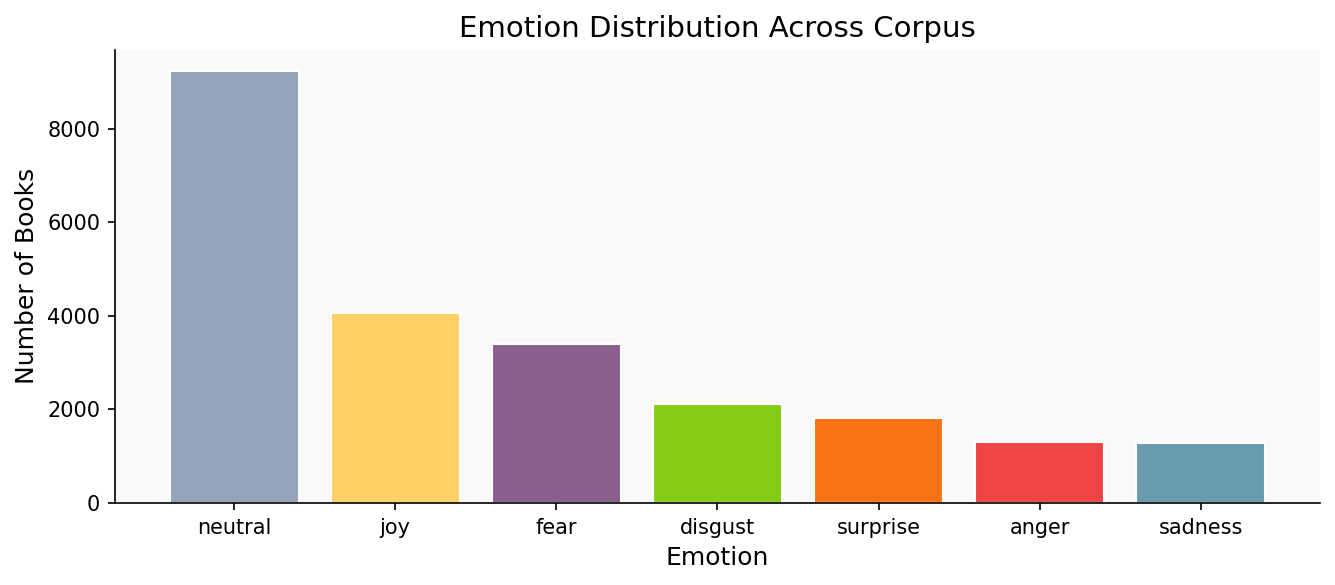

Saved: plot5_emotion_distribution.png


In [8]:
EMOTION_PATH = Path('data/processed/books_with_emotions.csv')

if EMOTION_PATH.exists():
    df_emo = pd.read_csv(EMOTION_PATH)

    # Giả sử top_emotions là list dạng string, VD: "joy,sadness"
    # Tách ra và đếm từng emotion
    from collections import Counter
    emotion_counts = Counter()
    for row in df_emo['top_emotions'].dropna():
        for e in row.split(','):
            emotion_counts[e.strip()] += 1

    emotion_df = pd.DataFrame(emotion_counts.items(), columns=['emotion', 'count'])
    emotion_df = emotion_df.sort_values('count', ascending=False)

    fig, ax = plt.subplots(figsize=(9, 4))
    emotion_colors = {
        'joy':      '#FFD166',
        'sadness':  '#6A9AB0',
        'fear':     '#8C5E8B',
        'anger':    '#EF4444',
        'surprise': '#F97316',
        'disgust':  '#84CC16',
        'neutral':  '#94A3B8',
    }
    bar_colors = [emotion_colors.get(e, '#888') for e in emotion_df['emotion']]
    ax.bar(emotion_df['emotion'], emotion_df['count'], color=bar_colors, edgecolor='white')
    ax.set_title('Emotion Distribution Across Corpus')
    ax.set_xlabel('Emotion')
    ax.set_ylabel('Number of Books')
    plt.tight_layout()
    plt.savefig(FIGURE_PATH / 'plot5_emotion_distribution.png')
    plt.show()
    print('Saved: plot5_emotion_distribution.png')
else:
    print('books_with_emotions.csv not found — run 06_emotion_detection.ipynb first.')
    print('Placeholder chart skipped.')


## 8. Summary — 4 Key Insights

| # | Insight | Implication |
|---|---------|-------------|
| 1 | **Description length median ~120 words** with heavy right tail | Enough context for dense embeddings. Outliers (>500 words) may need truncation to 512 tokens before embedding. |
| 2 | **Category imbalance** — Fiction >> all others | Precision@K scores will vary a lot by query category. Balance test queries across genres to avoid inflated overall P@K. |
| 3 | **Publication bias toward 2000–2020** | Modern language dominates corpus. Queries using archaic vocabulary may return worse results for older books. |
| 4 | **Low correlation between num_pages / published_year and description_length** | Page count & published year are not proxies for description length. Safe to use description as standalone NLP feature. |

## 9. Save Figures List

In [9]:
figures = list(FIGURE_PATH.glob('*.png'))
print(f'Figures saved ({len(figures)}):')
for f in sorted(figures):
    print(f'  {f}')

Figures saved (17):
  reports/figures/description_length_raw.png
  reports/figures/eval_latency_quality.png
  reports/figures/eval_precision_bar.png
  reports/figures/missing_values.png
  reports/figures/plot1_description_length.png
  reports/figures/plot1_rating_distribution.png
  reports/figures/plot2_description_length.png
  reports/figures/plot2_top20_categories.png
  reports/figures/plot3_published_year.png
  reports/figures/plot3_top20_categories.png
  reports/figures/plot4_correlation_heatmap.png
  reports/figures/plot4_published_year.png
  reports/figures/plot5_correlation_heatmap.png
  reports/figures/plot5_emotion_distribution.png
  reports/figures/plot6_emotion_distribution.png
  reports/figures/plot6b_emotion_by_category.png
  reports/figures/top_categories_raw.png
